# 15 딥러닝 입문

자료 출처: [ISLP (An Introduction to Statistical Learning with Applications in Python)](https://www.statlearning.com/)

- [15.1 개요](#15.1-개요)
- [15.2 단층 신경망](#15.2-단층-신경망)
- [15.3 다층 신경망](#15.3-다층-신경망)
- [15.4 신경망 피팅](#15.4-신경망-피팅)
- [15.5 Keras를 사용한 MNIST 딥러닝](#15.5-Keras를-사용한-MNIST-딥러닝)

## 15.1 개요

**딥러닝**(deep learning)은 음성 인식, 텍스트 및 이미지 분류, 자율주행 등과 같은 복잡한 작업을 수행하는 데 사용되는 머신러닝 기법이다. 딥러닝은 머신러닝 및 인공지능 커뮤니티에서 매우 활발한 연구 영역으로서 그 초석은 **신경망**(neural network)이다. 신경망은 1980년대 후반에 각광을 받기 시작했다. 당시 기계학습자, 수학자, 통계학자 등 여러 분야에서 신경망의 특성을 분석함으로써 종합화가 이루어졌으며, 알고리듬이 개선되었고 방법론이 안정화되었다. 

그러다가 SVM(support vector machine), 부스팅, 랜덤 포레스트 등이 등장함에 따라 신경망에 대한 관심과 선호가 다소 떨어졌다. 그 이유 중 하나는 신경망은 손이 많이 가야 하는 반면, SVM 등 새로운 방법들은 더 자동적이기 때문이다. 또한 많은 문제에서 SVM 등 새로운 방법론이 제대로 훈련되지 않은 신경망보다 성능이 뛰어났다. 이것이 2000년대 들어 첫 10년 동안의 현상이었다.

그럼에도 불구하고 신경망 매니아의 핵심 그룹은 유례없이 커진 컴퓨팅 아키텍처와 데이터세트를 가지고 자신들의 기술을 더욱 강력하게 추진하고 있었다. 그리하여 2010년 이후 새로운 아키텍처와 추가 기능을 갖추어 **딥러닝**이라는 새로운 이름으로 다시 등장했으며, 이미지 및 비디오 분류, 음성 및 텍스트 모델링과 같은 일부 틈새 문제에 있어서 일련의 성공 사례를 보여주었다. 이러한 성공의 원인은 무엇보다 과학 및 산업에서 광범위한 디지털화로 더 큰 훈련 데이터세트가 사용가능해졌기 때문이다. 

이 장에서는 신경망과 딥러닝의 기초적인 부분에 대해서만 다룬다. 신경망 모형의 기본 구조와 피팅 절차에 대해서만 살펴보고, 이미지 분류를 위한 **합성곱 신경망**(CNN: Convolutional Neural Network), 시계열 및 여타 시퀀스를 위한 **순환 신경망**(RNN: Recurrent Neural Network) 등 좀 더 전문적 문제에 대해서는 다루지 않는다. 이 장은 딥러닝 전반을 이해하기 위한 기초적 내용이라고 보면 된다.  

독자들의 이해를 돕기 위해 이 장에서는 딥러닝 학습에서 연습용으로 자주 사용되는 **MNIST 손글씨 인식** 사례를 통해 신경망 분석에 대해 설명한다. 또한 Google에서 개발한 텐서플로(TensorFlow) 딥러닝 소프트웨어와 인터페이스하는 `keras` 모듈을 사용하여 MNIST 손글씨 인식 모델을 실행한다.

### ChatGPT Q&A

>**(단순)신경망, 합성곱 신경망(CNN: Convolutional Neural Network), 순환 신경망(RNN: Recurrent Neural Network)의 차이에 대해 간단히 알기 쉽게 설명해줘.**

---

>신경망(Neural Networks)은 뇌의 작동 방식을 모방하여 개발된 알고리즘으로, 데이터를 처리하고 패턴을 인식하는데 사용됩니다. 여기서 소개할 (단순)신경망, 합성곱 신경망(CNN), 순환 신경망(RNN)은 서로 다른 종류의 신경망으로, 각각 특정 유형의 문제 해결에 적합합니다.
>
>**(단순)신경망**
>- **정의:** 가장 기본적인 형태의 신경망으로, 입력층(input layer), 하나 이상의 은닉층(hidden layers), 그리고 출력층(output layer)으로 구성됩니다.
>- **용도:** 기본적인 분류(classification)나 회귀(regression) 문제에 사용됩니다.
>- **특징:** 모든 뉴런이 이전 층의 모든 뉴런과 연결되어 있는 완전 연결(fully connected) 구조를 가집니다.
>
>**합성곱 신경망(CNN)**
>- **정의:** 이미지나 비디오 처리에 특화된 신경망으로, 합성곱 층(convolutional layers)과 풀링 층(pooling layers)을 포함합니다.
>- **용도:** 이미지 인식, 비디오 분석, 이미지 분류, 얼굴 인식 등에 주로 사용됩니다.
>- **특징:** 공간적 계층 구조를 통해 이미지의 특징을 효과적으로 추출하고, 매개변수의 수를 줄여 계산 효율성을 높입니다.
>
>**순환 신경망(RNN)**
>- **정의:** 시퀀스 데이터(예: 시계열 데이터, 텍스트 등)의 순서가 중요한 정보를 포함하는 경우에 사용되는 신경망으로, 이전의 계산 결과를 현재의 입력과 함께 고려합니다.
>- **용도:** 자연어 처리(NLP), 음성 인식, 언어 번역, 시계열 분석 등에 적합합니다.
>- **특징:** 순환 구조를 통해 정보를 순차적으로 처리하며, 이전 시점의 정보를 기억하는 메모리 기능을 가집니다.
>
>이 세 종류의 신경망은 각각의 특성과 용도에 따라 다양한 문제 해결에 활용됩니다. 단순 신경망은 비교적 간단한 문제에, CNN은 시각적 데이터 처리에, RNN은 순서가 중요한 시퀀스 데이터 처리에 각각 최적화되어 있습니다.

### MNIST 데이터베이스

먼저 **MNIST**(Modified National Institute of Standards and Technology) 데이터베이스에 대해 소개한다. 이것은 손으로 쓴 숫자 이미지들을 모아놓은 대규모 데이터베이스로서 다양한 이미지 처리 시스템을 훈련시키는 데 자주 사용되며, 기계학습 분야의 훈련 및 테스트에도 널리 사용된다.

MNIST 데이터베이스에는 60,000개의 훈련 이미지와 10,000개의 테스트 이미지가 들어있다. 데이터베이스에 총 70,000개의 손으로 쓴 숫자들이 들어있는 것이다. 

그림 15.1은 MNIST 데이터베이스에 들어있는 숫자의 예를 보여준다. 여기에서 우리의 목표는 손글씨 숫자 이미지를 올바르게 분류하는 모델을 구축하는 것이다. 가장 간단하게는 우리가 앞에서 배운 선형 회귀 모델부터 시작해서 아주 다양한 솔루션을 생각해볼 수 있는데, 여기에서는 신경망 모델에 초점을 맞춘다.  

**그림 15.1.** MNIST 손글씨 숫자 예. 각 숫자 이미지에는 $28 \times 28$, 즉 784개 픽셀이 있으며, 각 픽셀은 해당 픽셀이 얼마나 어두운지를 8비트 숫자(0~255)로 측정해 놓았다. 아래 그림의 맨 윗줄에 있는 3, 5, 8 세 개 숫자에 대해서는 개별 픽셀이 보이도록 맨 아래에 확대해 놓았다.

![MNIST 손글씨 숫자 예](https://raw.githubusercontent.com/pilsunchoi/images/main/15-1.png)

- 그림 출처: ISLP, FIGURE 10.3

MNIST 데이터베이스의 각 이미지는 $p = 28 \times 28 = 784$ 픽셀로 구성돼있으며, 각 픽셀은 0에서 255 사이의 8비트 회색조 값을 갖는다. 다시 말하면, 각 이미지는 784개의 입력변수를 갖고 있고, 각 입력변수는 256가지의 값을 가질 수 있는 것이다. 각 이미지에 담긴 이러한 픽셀 정보가 입력 벡터 $X$에 저장돼있다고 하자. 

한편 MNIST에서 출력($Y$)은 단일의 숫자 변수를 10개의 더미변수로 구성된 벡터 $Y = (Y_0, Y_1, ... ,Y_9)$ 형태로 전환시켜 사용한다. 머신러닝에서는 이것을 **원-핫 인코딩**(one-hot encoding)이라고 부른다. 즉 분류하고자 하는 클래스(레이블) 개수만큼의 자릿수를 만들어 해당 클래스에 대해서는 1을 부여하고 나머지는 0을 채워서 숫자화하는 방식이다. 가령 손글씨 숫자가 1인 경우, $Y = (0, 1, 0, 0, ... ,0)$으로 표현된다.

손글씨 숫자를 인식하는 문제는 1980년대 후반 AT&T 벨 연구소 등 여러 곳에서 신경망 기술의 개발을 가속화한 촉매였다. 이러한 종류의 패턴 인식 작업은 인간에게는 아주 간단하지만, 기계에게는 간단하지 않으며, 인간 수준으로 신경망 아키텍처를 개선하는 데 30년 이상이 걸렸다.

MNIST 손글씨 숫자 분류 성과와 관련해서 오분류율이 가장 높은(즉 분류 성과가 가장 열등한) 케이스는 데이터 전처리(data preprocessing) 없이 간단한 선형 분류기를 적용하는 모델로서 오분류율이 12% 수준이다. 여러 연구자들이 신경망 기법을 적용하여 분류 성과를 크게 개선해왔는데, 주요 연구 몇가지를 살펴보면(Wikipedia, "[MNIST database](https://en.wikipedia.org/wiki/MNIST_database)"), Kussul과 Baidyk(2004)는 Rosenblatt의 퍼셉트론 원리를 기반으로 하는 3개의 뉴런층이 있는 신경 분류기인 LIRA라는 분류기를 사용하여 0.42%의 오분류율을 달성했다. 2011년에는 유사한 신경망 시스템을 사용하는 연구자(Cireşan 등)들이 이전의 최고 결과보다 개선된 0.27%의 오분류율을 보고했다. 계속해서 Cireşan 등(2012)은 신경망 기법을 사용하여 MNIST 데이터베이스에서 "인간에 가까운 성능"을 달성했다. Wan 등(2013)은 DropConnect를 사용한 신경망의 정규화에 기반한 접근 방식으로 0.21%의 오분류율을 달성했다. 2016년 단일 CNN의 최고 성능은 0.25%의 오분류율이었다(SimpleNet, 2016). 2018년 8월 현재, 데이터 증강(data augmentation)을 사용하지 않고 도달한 단일 CNN의 최고 성능은 0.25%의 오분류율이다. 또한 Parallel Computing Center(우크라이나)는 단 5개의 CNN으로 0.21%의 오분류율을 얻었다. 2018년 버지니아 대학교 시스템정보공학부의 연구원들(Kowsari 등)은 3가지 종류의 신경망(완전 연결, 순환, 합성곱 신경망)을 동시에 쌓아 0.18%의 오분류율을 달성했다.

## 15.2 단층 신경망

MNIST 손글씨 인식 문제에서 입력변수 $X$는 784개 픽셀 정보이다. 즉 입력변수가 784개인 셈이다. 또한 출력변수 $Y$는 앞에서 언급했듯이 원-핫 인코딩으로 표시된 해당 숫자의 클래스(레이블)이다. 

이처럼 $X = (X_1, X_2, ... , X_p)$의 입력변수 벡터를 사용하여 출력변수 $Y$를 예측하는 문제에 있어서 신경망은 비선형 함수 $f(X)$를 만들어 이를 수행한다. 사실 비선형 예측 모델은 트리나 부스팅 등 아주 다양한 기법들이 있는데, 이러한 방법과 신경망이 구별되는 것은 모델의 특별한 구조이다. 

아래 그림 15.2는 4개($p = 4$)의 예측변수를 사용하여 정량적 반응변수를 모델링하는 간단한 신경망을 보여준다. 신경망에서는 $X_1, ... , X_4$를 **입력층**(input layer)의 **유닛**(unit)이라고 부른다. 아래 그림을 보면, 각 입력층 유닛에서 화살표가 나오는데, 이는 입력층의 각 입력 정보가 $K$개의 **은닉층**(hidden layer) 유닛 각각에 공급됨을 나타낸다($K=5$로 했을 때). 

**그림 15.2.** 은닉층이 한 개 있는 신경망. 은닉층은 입력변수 $X_1, X_2,  . . . , X_p$의 선형조합을 비선형 변환시켜 활성화 유닛 $A_k = h_k(X)$로 전환시킨다. 이러한 활성화 유닛 $A_k$는 직접 관찰된 것이 아니라 입력변수가 전환된 것이다. 활성화 함수인 $h_k(·)$는 고정돼있지 않고 신경망 훈련 중에 학습된다. 출력층은 활성화 유닛 $A_k$를 입력으로 사용하여 함수 $f(X)$를 생성하는 선형 모델로 설정된다.

![은닉층이 한 개 있는 신경망](https://raw.githubusercontent.com/pilsunchoi/images/main/15-2.png)

- 그림 출처: ISLP, FIGURE 10.1

이상에서 설명한 신경망 모델을 하나의 식으로 표현하면 다음과 같다. 

$$
\begin{equation} \tag{15.1}
\begin{aligned}
f(X) & = \beta_0 + \textstyle\sum_{k=1}^{K} \beta_k \cdot h_k(X) \\
     & = \beta_0 + \textstyle\sum_{k=1}^{K} \beta_k \cdot g \left(w_{k0}+\textstyle\sum_{j=1}^{p}w_{kj}X_j \right)
\end{aligned}
\end{equation}
$$

그림 15.2에서 보는 것처럼, 이것은 두 단계로 만들어진 것인데, 먼저 은닉층에 있는 $K$개의 활성화 $A_k$는 다음과 같이 입력변수 $X_1, ... , X_p$의 **선형조합**(linear combinations)의 함수 형태로 계산된다.

$$ A_k = h_k(X) = g \left(w_{k0}+\textstyle\sum_{j=1}^{p}w_{kj}X_j \right) \tag {15.2}$$ 

여기서 $g(z)$를 **활성화 함수**(activation function)라고 부른다. 이렇게 계산한 은닉층의 $K$개 활성화가 **출력층**(output layer)으로 공급되어 다음과 같이 그것을 다시 입력변수로 하는 선형 회귀 모델이 된다.

$$ f(X) = \beta_0 + \sum_{k=1}^{K} \beta_k A_k $$ 

결국 이 식에 들어있는 모든 파라미터(parameter), 즉 $\beta_0, ..., \beta_K$ 및 $w_{10}, ..., w_{Kp}$를 주어진 데이터로 추정하여 정확도가 높은(즉 손글씨를 정확히 추정하는) 모델을 만드는 것이 최종 목표이다. 

활성화 함수의 경우, 신경망 초기 사례에서는 $X_1, ... , X_p$의 선형조합을 0과 1 사이의 확률로 변환하기 위해 다음과 같은 **시그모이드**(sigmoid) 활성화 함수가 많이 사용되었다(이는 로지스틱 회귀에서 사용된 것과 동일한 함수이다).

$$ g(z) = \frac{e^z}{1+e^z} = \frac{1}{1+e^{-z}} $$ 

그러나 요즘 신경망에서 선호되는 활성화 함수는 다음 형식을 취하는 **ReLU**(rectified linear unit) 활성화 함수이다.

$$ g(z) = (z)_+ = 
\begin{cases}
0  & \text{if $z<0$} \\
z & \text{otherwise}
\end{cases} $$ 

**그림 15.3.** 활성화 함수.  ReLU 함수는 시그모이드 함수에 비해 계산이 간단하여 효율적이다. 아래 그림은 비교의 편의를 위해 ReLU 함수의 값을 1/5로 축소한 것이다.

![ReLU 함수](https://raw.githubusercontent.com/pilsunchoi/images/main/15-3.png)

- 그림 출처: ISLP, FIGURE 10.2

ReLU 활성화는 시그모이드 활성화보다 더 효율적으로 계산하고 저장할 수 있다. 0을 경계로 꺾이는 형태이지만 식 15.2에서 보는 것처럼 $X$의 선형 함수에 적용시키기 때문에 상수항 $w_{k0}$이 변곡점을 이동시키는 역할을 하게 된다.

결국 그림 15.2에 묘사된 신경망 모델은 $X$의 5가지 다른 선형조합을 통해 5가지 새로운 특성(feature)을 도출한 다음, 이들 각각을 활성화 함수 $g(·)$를 통해 변환하며, 최종 모델은 이렇게 생성된 활성화 변수들에 대해 선형으로 설정한 것이다. 원래 신경망이라는 이름은 이러한 은닉층 유닛들이 인간 뇌의 뉴런과 유사하다고 생각하는 데서 유래했다.

신경망에서는 활성화 함수 $g(·)$의 비선형성이 중요한 역할을 한다. 왜냐하면 이것이 없으면 식 15.1의 모델 $f(X)$가 단순히 $X_1, ... ,X_p$의 선형 모델이 되기 때문이다. 비선형 활성화 함수를 사용하면 복잡한 비선형성 및 상호작용(interaction) 효과를 포착할 수 있다. 가장 간단한 예로 $p = 2$의 입력변수 $X = (X_1,X_2)$와 $K = 2$의 은닉 유닛 $h_1(X)$ 및 $h_2(X)$, 그리고 활성화 함수 형태로 $g(z) = z^2$를 생각해보자. 여기에서 주어진 파라미터들이 다음과 같다고 해보자.

$$
\begin{matrix}
\beta_0=0, & \beta_1=\frac{1}{4}, & \beta_2=-\frac{1}{4}, \\
w_{10}=0, & w_{11}=1, & w_{12}=1, \\
w_{20}=0, & w_{21}=1, & w_{22}=-1, \\
\end{matrix}$$

이것은 식 15.2에 의해 다음을 의미한다.

$$ h_1(X) = (0+X_1+X_2)^2, \\ 
h_2(X) = (0+X_1-X_2)^2 $$

이들 두 개의 활성화를 식 15.1에 집어 넣으면 다음을 얻는다.

$$ \begin{align}
f(X) & = 0 + \tfrac{1}{4} \cdot (0+X_1+X_2)^2 - \tfrac{1}{4} \cdot (0+X_1-X_2)^2 \\
& = \tfrac{1}{4} \left[ (X_1+X_2)^2-(X_1-X_2)^2 \right]\\
& = X_1X_2
\end{align} $$ 

이처럼 두 가지 선형조합을 비선형 변환시켜 더함으로써 상호작용 항인 $X_1X_2$에 도달할 수 있는 것이다. 

신경망을 피팅하려면 식 15.1에서 미지의 파라미터를 추정해야 한다. 반응변수 $Y$가 정량적이라면 일반적으로 다음과 같은 제곱오차손실(squared-error loss)을 최소화시키는 파라미터를 선택하게 된다. 

$$ \sum_{i=1}^n (y_i-f(x_i))^2 \tag {15.3}$$

## 15.3 다층 신경망

최근의 신경망은 일반적으로 하나보다 많은 은닉층를 갖고 있으며, 또한 각 은닉층에 아주 많은 유닛를 가지고 있다. 이론적으로는 은닉층이 하나이더라도 유닛의 숫자를 늘려나가면 대부분의 함수를 근사화할 수 있다. 그러나 적절한 크기의 은닉층을 여러 개 사용하면 좋은 솔루션을 찾는 학습 작업이 훨씬 쉬워진다.

그림 15.4는 우리가 MNIST 숫자 분류 작업에 사용하는 다층 신경망 구조를 보여준다. 앞의 그림 15.2와는 여러 면에서 다른데, 우선 은닉층이 하나가 아니라 두 개로서, 레이어 $L_1$에는 256개 유닛을 두고, 레이어 $L_2$에는 128개 유닛을 두고자 한다. 여기에서 각 레이어(층)의 유닛 숫자는 임의로 선택한 것이다. 앞에서 설명했듯이 출력변수는 하나가 아닌 10개의 더미변수로 이루어진 벡터로 돼있다. 이들 10개의 변수는 최종적으로는 하나의 정성적 변수를 나타낸다(즉 0부터 9까지의 정수 중 하나). 

**그림 15.4.** MNIST 데이터베이스 분류에 사용되는 두 개의 은닉층과 다중 출력이 있는 신경망 다이어그램. 입력층에는 픽셀 개수에 해당하는 $p = 784$의 유닛이 있고, 은닉층에는 $K_1 = 256$ 및 $K_2 = 128$의 유닛이 있고, 출력층은 10개 유닛을 갖는다. 

![신경망 다이어그램](https://raw.githubusercontent.com/pilsunchoi/images/main/15-4.png)

- 그림 출처: ISLP, FIGURE 10.3

이런 식으로 신경망을 설계할 경우 여기에는 절편(intercept)을 포함하여 총 235,146개의 파라미터가 들어있게 된다. 딥러닝에서는 절편을 **편향**(bias)이라고 하고, 이를 포함한 모든 파라미터를 **가중치**(weight)라고 부른다. 

그림 15.4에서 첫 번째 은닉층은 앞의 식 15.2와 마찬가지로 다음과 같이 표현된다. 

$$
\begin{equation} \tag{15.4}
\begin{aligned}
A_k^{(1)} & = h_k^{(1)}(X) \\
          & = g \left(w_{k0}^{(1)}+\textstyle\sum_{j=1}^{p}w_{kj}^{(1)}X_j \right) 
\end{aligned}
\end{equation}
$$

여기에서 $k = 1, . . . ,K_1$이다. 또한 두 번째 은닉층은 첫 번째 은닉층의 활성화 유닛 $A^{(1)}_k$를 입력으로 하여 새로운 활성화 유닛을 계산한다.

$$
\begin{equation} \tag{15.5}
\begin{aligned}
A_{\ell}^{(2)} & = h_{\ell}^{(2)}(X) \\
               & = g \left(w_{\ell 0}^{(2)}+\textstyle\sum_{k=1}^{K_1}w_{\ell k}^{(2)}A_{k}^{(1)} \right)
\end{aligned}
\end{equation}
$$

여기에서 $\ell= 1, . . . ,K_2$이다. 두 번째 은닉층 $A^{(2)}_\ell = h^{(2)}_\ell(X)$는 궁극적으로 입력 벡터 $X$의 함수이다. 왜냐하면 두 번째 은닉층의 각 유닛은 첫 번째 은닉층의 활성화 유닛인 $A^{(1)}_k$의 함수이며, 이것은 다시 $X$의 함수이기 때문이다. 이것은 더 많은 은닉층이 있는 경우에도 마찬가지이다. 결국 신경망은 이와 같은 일련의 변환을 통해 $X$의 상당히 복잡한 변환을 구축할 수 있으며 궁극적으로 이를 출력층에 특성(feature)으로 제공하게 된다.

식 15.4 및 5에서 가령 $h^{(2)}_\ell(X)$ 및 $w^{(2)}_{\ell j}$에서 위첨자 $^{(2)}$는 활성화 함수 및 가중치(계수)가 두 번째 층에 속하는 것을 의미한다. 그림 15.4에서 맨 아래쪽에 $\mathbf W_1$ 표기는 입력층에서 첫 번째 은닉층 $L_1$으로 공급되는 전체 가중치 행렬을 나타낸다. 이 행렬에는 $785 \times 256 = 200,960$개의 원소(element)가 있다. $785 \times 256$에서 256은 우리가 설정한 첫 번째 은닉층 활성화 유닛의 개수이고, 이들 각 유닛에 대해 식 15.4에서 알 수 있듯이 절편(또는 편향) 항을 포함하여 총 785개의 가중치(계수)가 있다.  

이렇게 얻은 $A^{(1)}_k$는 다시 $257 \times 128 = 32,896$개의 원소를 가진 행렬 $\mathbf W_2$를 통해 두 번째 은닉층 $L_2$에 공급된다. 바로 앞의 설명과 마찬가지로, $257 \times 128$에서 128은 우리가 설정한 두 번째 은닉층의 활성화 유닛 개수이고, 이들 각 유닛에 대해 식 15.5에서 알 수 있듯이 절편(또는 편향) 항을 포함할 경우 총 257개의 가중치(계수)가 있다. 

마지막으로 출력층의 경우에는 반응변수가 하나가 아니라 10개라는 점은 앞에서 설명한 대로이다. 이 출력층의 구조를 두 단계로 생각해볼 수 있는데, 첫 번째 단계는 단층 모델인 식 15.1처럼 10개의 서로 다른 선형 모델을 계산하는 것이다.

$$ \begin{align}
Z_m & = \beta_{m0}+\textstyle\sum_{\ell=1}^{K_2}\beta_{m\ell}h_{\ell}^{(2)}(X) \\
& = \beta_{m0}+\textstyle\sum_{\ell=1}^{K_2}\beta_{m\ell}A_{\ell}^{(2)}
\end{align} $$ 


여기에서 $m = 0, 1, . . . , 9$이다. 가중치 행렬 $\mathbf B$의 원소 개수는 $129 × 10 = 1,290$개가 된다. 여기에서 10은 반응변수의 클래스 개수(즉 0~9)를 의미하고, 각 클래스에 대해 위 식에서 알 수 있듯이 절편 항을 포함할 경우 총 129개의 가중치(계수)가 있다.

만약 10개의 반응변수가 모두 정량적 변수라면, 그림 15.4에서 $f_m(X) = Z_m$으로 설정하면 된다. 이 경우 $Y_m = \beta_{m0} + \sum _{\ell=1}^{K_2} \beta_{m \ell} A^{(2)}_\ell$이 된다. 그러나 우리는 다항 로지스틱 회귀에서와 같이 추정치가 각 클래스의 확률, 즉 $f_m(X) = {\rm Pr}(Y = m \mid X)$이기를 원한다. 그래서 MNIST 손글씨 분류 모델에서 우리는 다음과 같은 소위 ***softmax*** 활성화 함수를 사용한다.

$$ f_m(X) = {\rm Pr}(Y=m \mid X) = \frac{e^{Z_m}}{\textstyle\sum_{\ell=0}^{9}e^{Z_\ell}} \tag {15.6}$$ 

여기에서 $m = 0, 1, . . . , 9$이다. 이렇게 하면 $f_m(X)$에 의해 추정된 10개의 숫자가 확률처럼 작동한다(즉 음수가 아니며, 10개 숫자의 합이 1이 됨). 우리의 최종 목표는 분류인데, 우리 모델이 실제로 하는 것은 10개 숫자 클래스 각각에 속할 확률을 추정한다. 그런 다음 어느 클래스의 확률이 가장 높은지를 따져 그 숫자 클래스에 해당 이미지를 할당하게 된다.

계수를 추정하는 방법은 다음과 같은 **음의 다항 로그가능도**(negative multinomial log-likelihood)를 최소화하는 방식을 취한다.

$$ -\sum_{i=1}^{n}\sum_{m=0}^{9}y_{im}\log(f_{m}(x_i)) \tag {15.7}$$ 

이것을 **교차 엔트로피**(cross-entropy)라고도 한다. 이것은 우리가 앞에서 배운 이항(binary) 로지스틱 회귀를 일반화시킨 것이라고 할 수 있다. 만약 반응변수가 우리 경우처럼 정성적이 아니라 정량적이라면 앞의 식 15.3에서 설명한 것처럼 제곱오차손실을 최소화한다.

## 15.4 신경망 피팅

만약 MNIST 손글씨 분류를 (위에서 설명한 신경망이 아니라) 다항 로지스틱 회귀를 이용하여 수행한다면 추정해야 하는 계수는 총 $785 × 9 = 7,065$개가 된다. 앞에서 설명한 대로 각 관측(즉 손글씨 이미지) 별로 $X$ 변수의 개수가 784개인 데다 절편까지 고려하면 총 785개가 되고, 클래스가 총 10개인 경우 9개 클래스에 대해서만 모델링을 하면 되기 때문이다(참고로 앞에서 배운 이항 로지스틱 모델의 경우, $X$ 변수 개수가 가령 784개라면 추정 계수는 절편 포함해서 총 $785 × 1 = 785$개임).

그런데 MNIST 손글씨 분류를 위에서 설명한 그림 15.4와 같은 신경망으로 수행할 경우에는 계수의 숫자가 앞에서 설명한 대로 $\mathbf W_1$ 200,960개, $\mathbf W_2$ 32,896개, $\mathbf B$ 1,290개를 모두 합하면 총 235,146개이다. 다항 로지스틱 회귀의 계수 숫자(7,065)의 33배가 넘는다. 훈련 세트의 관측이 60,000개이기 때문에 **관측보다 거의 4배나 많은 계수를 추정해야** 한다! 

신경망을 피팅할 때 이 문제를 어떻게 해결하는지 세부적으로는 상당히 복잡하기 때문에 여기서는 간략한 개요만 설명한다. 앞의 그림 15.2에 표시된 간단한 신경망에서 시작해보자. 신경망 모델 식 15.1에서 파라미터는 $\beta = (\beta_0, \beta_1, ..., \beta_K)$ 및 $w_k=(w_{k0},w_{k1}, ..., w_{kp})$, $k = 1, ,K$이다. 관측 $(x_i, y_i)$, $i =1, ..., n$이 주어지면, 반응변수 $Y$가 정량적인 경우, 다음과 같은 비선형 최소제곱(nonlinear least squares) 방식으로 모델을 피팅할 수 있다.

$$ \underset{ \{ w_k \}_1^K,\text{ } \beta} {\rm minimize } \text{ } \frac{1}{2} \sum_{i=1}^n (y_i-f(x_i))^2 \tag {15.8}$$

여기에서 

$$ f(x_i) = \beta_0 + \textstyle\sum_{k=1}^{K}\beta_k \cdot g\left(w_{k0}+\textstyle\sum_{j=1}^{p}w_{kj}x_{ij}\right). $$ 

식 15.8의 최소화 문제는 단순해 보이지만 해를 찾는 것은 간단한 일이 아니다. 우선 최소화 문제가 파라미터들에 대해 비볼록(nonconvex)이라서 솔루션이 여러 개 있을 수 있다. 예를 들어, 그림 15.5는 단일 파라미터 $\theta$의 간단한 비볼록 함수를 보여준다. 그림에서 보듯이 두 개의 솔루션이 있는데, 왼쪽은 **로컬**(local) 최소값이고 오른쪽은 **글로벌**(global) 최소값이다. 

최소화가 간단하지 않은 또 다른 문제는 식 15.1만 해도 가장 단순한 신경망이라는 점이다. 우리는 일반적으로 이보다는 훨씬 더 복잡한 문제에 직면하게 된다. 신경망을 피팅할 때 이러한 문제들을 극복하고 과적합을 막기 위해 일반적으로 다음 두 가지 전략이 사용된다.

- **느린 학습**(slow learning): 모델은 **경사하강**(gradient descent) 방식이라 불리는 다소 느린 **반복적**(iterative) 방식으로 피팅된다. 그 과정에서 과적합이 감지되면 피팅이 중지된다.

- **정규화**(regularization): lasso 또는 ridge와 같이 파라미터에 페널티를 부과한다.

**그림 15.5.** 1차원 $\theta$에 대한 경사하강법 그림. 목적함수 $R(\theta)$는 볼록하지 않고 두 개의 최소값을 가진다. 하나는 $\theta = −0.46$(로컬 최소값)이고 다른 하나는 $\theta = 1.02$(글로벌 최소값)이다. 일반적으로 출발점은 무작위로 선택하는데, 가령 $\theta_0$ 값에서 출발하여 더 이상 아래로 내려갈 수 없을 때까지 기울기(gradient)에 대해 내리막으로 이동한다. 이 그림에서 경사하강법으로 7스텝을 거쳐 (운좋게도 로컬 최소값이 아니라) 글로벌 최소값에 도달했다.

![1차원 theta에 대한 경사하강법](https://raw.githubusercontent.com/pilsunchoi/images/main/15-5.png)

- 그림 출처: ISLP, FIGURE 10.17

$\theta$가 모든 파라미터를 표시하는 벡터라고 하자. 그러면 식 15.8에서 목적함수를 다음과 같이 쓸 수 있다.

$$ R(\theta) = \frac{1}{2} \sum_{i=1}^{n}(y_i-f_{\theta}(x_i))^2 \tag {15.9}$$ 

경사하강법의 개념 자체는 매우 간단하다.

1. $\theta$의 모든 파라미터에 대해 임의의 $\theta^0$에서 출발한다. 그 출발 시점을 $t=0$이라 하자.


2. 목표함수인 식 15.9가 더 이상 감소하지 않을 때까지 다음 두 스텝을 반복한다.

	(a) $\theta^{t+1} = \theta^{t} + \delta$가 목적함수를 감소시키도록 $\theta$를 약간 변화시키는 벡터 $\delta$를 찾는다. 즉, $R(\theta^{t+1}) \lt R(\theta^{t})$을 만족하는 $\delta$를 찾는다.    
	(b) $t \gets t+1$로 변경한다.
    
그림 15.5에서 우리가 산속의 어떤 한 지점에 서 있다고 생각해보자. 우리의 목표는 이 산을 걸어 내려와 바닥에 도달하는 것이다. 단, 우리는 눈으로 보면 안되고 오직 오르막과 내리막 걸음만을 구분할 수 있다고 해보자. 경사하강법은 모든 걸음을 내리막으로 하면 된다는 간단한 원리이다. 이 그림의 경우 우리는 운이 좋았다. 왜냐하면 임의의 출발점 $\theta^0$에서 시작할 경우, 로컬 최소값이 아니라 글로벌 최소값에 도달하기 때문이다. 경사하강법으로 항상 글로벌 최소값을 달성할 수 있지는 않겠지만, 최소한 (괜찮은) 로컬 최소값에는 도달할 수 있을 것이다. 

### 역전파

식 15.9에서 목표 $R(\theta)$를 감소시키기 위해서는 $\theta$를 어떻게 변화시켜야 할까? 앞서 설명한 대로 기울기(gradient)가 이에 대한 답을 제공한다. 어떤 현재값 $\theta=\theta^{t}$에서 평가된 $R(\theta)$의 기울기는 해당 포인트에서의 편도함수(partial derivatives) 벡터다.

$$ \nabla R(\theta^{t}) = \left.\frac{\partial R(\theta)}{\partial \theta}\right|_{~\theta=\theta^{t}} \tag {15.10}$$ 

여기에서 첨자 $\theta=\theta^{t}$은 도함수 벡터를 계산한 후 현재값인 $\theta^{t}$에서 벡터를 평가한다는 것을 의미한다. 도함수는 $\theta$-공간에서 $R(\theta)$가 가장 빠르게 증가하는 방향을 제공한다. 이때 경사하강법의 개념은 (우리가 원하는 것은 오르막이 아니라 내리막이기 때문에) 아래 식과 같이 $\theta$를 도함수의 **반대 방향**으로 약간 이동시키는 것을 의미한다(즉 도함수의 일정 크기를 더하는 것이 아니라 빼줌).

$$ \theta^{t+1} \gets \theta^{t} - \rho \nabla R(\theta^{t}) $$

여기에서 $\rho$를 **학습률**(learning rate)이라고 한다. $\rho$의 값이 충분히 작은 경우(가령 $\rho$=0.001), 위 스텝은 목표함수 $R(\theta)$를 감소시킨다. 즉, $R(\theta^{t+1}) \le R(\theta^{t})$이다. 만약 이런 식으로 진행해서 기울기 벡터가 0에 이르면 목표의 최소값에 도달했을 것이다.

위의 경우 식 15.10의 계산은 매우 간단하다. 신경망 구조가 훨씬 더 복잡해져도 미분의 **연쇄법칙**(chain rule) 때문에 도함수 계산은 간단하다. 즉 $R(\theta) = \sum _{i=1}^{n}R_i(\theta) = \frac{1}{2}\sum _{i=1}^{n}(y_i-f_{\theta}(x_i))^2$에서 보듯이 $R(\theta)$는 합으로 구성돼있으므로 이에 대한 기울기 역시 $n$개의 관측에 대한 합이다. 합을 구성하는 $n$개의 항 중에서 $i$번째 항 하나만 살펴보면 다음과 같다. 

$$ R_i(\theta) = \frac{1}{2}\left(y_i-\beta_0-\sum_{k=1}^{K}\beta_k \cdot g(w_{k0}+\sum_{j=1}^{p}w_{kj}x_{ij})\right)^2 $$ 

표현의 단순화를 위해 $z_{ik}= w_{k0} + \sum _{j=1}^{p}w_{kj}x_{ij}$로 놓은 다음, 위 식에 대해 먼저 $\beta_k$에 대해 미분을 취한다.

$$
\begin{equation} \tag{15.11}
\begin{aligned}
\frac{\partial R_i(\theta)}{\partial \beta_k} & = \frac{\partial R_i(\theta)}{\partial f_{\theta}(x_i)} \cdot \frac{\partial f_{\theta}(x_i)}{\partial \beta_k} \\
& = -(y_i-f_{\theta}(x_i))\cdot g(z_{ik})
\end{aligned}
\end{equation}
$$

이번에는 $w_{kj}$에 대해 미분을 취한다.

$$
\begin{equation} \tag{15.12}
\begin{aligned}
\frac{\partial R_i(\theta)}{\partial w_{kj}} & = \frac{\partial R_i(\theta)}{\partial f_{\theta}(x_i)} \cdot \frac{\partial f_{\theta}(x_i)}{\partial g(z_{ik})} \cdot \frac{\partial g(z_{ik})}{\partial z_{ik}} \cdot \frac{\partial z_{ik}}{\partial w_{kj}} \\
& = -(y_i-f_{\theta}(x_i))\cdot \beta_k \cdot g'(z_{ik}) \cdot x_{ij} 
\end{aligned}
\end{equation}
$$

식 15.11과 12 모두에 잔차 $y_i-f_{\theta}(x_i)$가 들어있다. 따라서 식 15.11이 의미하는 것은 활성화 함수 $g(z_{ik})$ 값만큼 잔차의 일부가 각 은닉 유닛에 반영된다는 것이다. 마찬가지로 식 15.12에서도 입력 $j$가 은닉 유닛 $k$를 통해 비슷한 식으로 반영된다. 따라서 미분 행위는 연쇄법칙을 통해 각 파라미터에 잔차의 일부를 할당한다. 이 과정을 신경망에서는 **역전파**(backpropagation)라고 부른다. 

### 정규화와 확률적 경사하강법

경사하강법은 일반적으로 로컬 최소값에 도달하기 위해 엄청나게 많은 스텝을 거쳐야 한다. 이에 따라 이 과정을 가속화하기 위한 여러 개선책이 개발되었다. 

우선 데이터세트의 크기가 크면 모든 $n$개 관측에 대해 기울기를 계산하는 대신 관측의 일부분, 즉 **미니배치**(minibatch)를 샘플링할 수 있다. 이 프로세스를 **확률적 경사하강법**(SGD: stochastic gradient descent)이라고 부른다. 

앞에서 설명했듯이 우리가 MNIST 숫자 인식 문제에 사용하는 다층 신경망(그림 15.4)에는 235,000개 이상의 가중치가 있으며 이는 훈련 관측 크기의 약 4배이다. 이처럼 추정해야 하는 파라미터의 개수가 관측에 비해 많은 상황에서 과적합(overfit)을 피하기 위해서는 **정규화**(regularization)가 필수적이다. 이것은 목적함수(식 15.7)에 다음과 같이 페널티 항을 추가한 것이다.

$$ R(\theta;\lambda) = -\sum_{i=1}^{n}\sum_{m=0}^{9}y_{im}\log(f_{m}(x_i)) + \lambda \sum_{j} \theta_j^2 $$ 

조정 파라미터 $\lambda$는 종종 어떤 임의의 작은 값으로 사전 설정되거나, 또는 검증 세트(validation-set)를 이용해 최적치를 구한다. 또한 층별로 각 가중치 그룹에 대해 서로 다른 $\lambda$ 값을 사용할 수도 있다. 가령 $\mathbf W_1$과 $\mathbf W_2$에 대해서는 페널티를 부과하지만 출력층의 가중치는 상대적으로 많지 않기 때문에 $\mathbf B$에 대해서는 전혀 페널티를 부과하지 않는 방식을 생각해볼 수 있다.

아래 그림 15.6은 MNIST 데이터에 대한 신경망 훈련 과정을 측정한 몇 가지 지표들을 보여준다. 여기에서 미니배치 크기는 기울기 업데이트당 128개의 관측이다. 그림에서 수평축 레이블인 **에포크**(epoch)는 피팅 알고리듬이 훈련 세트를 통과하는 횟수를 말한다. 이 신경망의 경우, 훈련을 마치는 시점을 결정하기 위해 검증 세트로 전체 훈련 관측의 20%가 사용되었다. 따라서 훈련에 실제로 사용된 관측은 전체 60,000개의 80%인 48,000개이다. 이렇게 본다면 에포크 당, 즉 훈련 세트에 피팅 알고리듬이 한 번 통과할 때 48,000/128 ≈ 375번의 기울기 업데이트가 이루어지는 것이다. 

**그림 15.6.** 앞의 그림 15.4에 묘사된 MNIST 신경망에 대한 목적함수 값(왼쪽 그림)과 오분류율(오른쪽 그림)을 훈련 에포크 별로 그린 것이다. 목적함수(또는 손실함수)는 식 15.7의 로그가능도를 나타낸다.

![목적함수 값과 오분류율](https://raw.githubusercontent.com/pilsunchoi/images/main/15-6.png)

- 그림 출처: ISLP, FIGURE 10.18

### 드롭아웃 학습

**드롭아웃**(dropout)은 비교적 새롭고 효율적인 정규화 방식이다. 랜덤 포레스트(random forest)에서 영감을 얻은 것으로 모델을 피팅할 때 층(layer)에서 유닛을 일정 비율($\varphi$)만큼 무작위로 제거하는 것을 말한다. 그림 15.7은 드롭아웃 학습을 그림으로 보여준다. 이것은 훈련 관측이 처리될 때마다 수행된다. 살아남은 유닛에 대해서는 제거된 것들만큼 그 가중치를 보상하기 위해 $1/(1-\varphi)$배만큼 확대시킨다. 

**그림 15.7.** 드롭아웃 학습. 왼쪽: 완전히 연결된 신경망. 오른쪽: 입력층 및 은닉층에 드롭아웃이 있는 신경망. 제거되는 회색 노드는 무작위로 선택되며 훈련에서 무시된다.

![드롭아웃 학습](https://raw.githubusercontent.com/pilsunchoi/images/main/15-7.png)

- 그림 출처: ISLP, FIGURE 10.19

### 네트워크 튜닝

그림 15.4의 신경망은 비교적 간단한 것임에도 불구하고 추정 성과에 영향을 미치는 여러 선택이 존재한다.

- 은닉층 개수와 각 은닉층당 유닛의 수.


- 정규화 조정 파라미터: 여기에는 드롭아웃 비율 $\varphi$와 lasso 및 ridge 정규화의 강도 $\lambda$가 포함되며, 이들은 일반적으로 각 레이어에서 별도로 설정된다.


- 확률적 경사하강법의 세부사항: 최적화 방법, 배치(batch) 크기, 에포크 수 등이 여기에 포함된다.

이와 같은 선택은 추정 성과에 상당한 차이를 만들 수 있다. 아래 MNIST 예제 실행 결과를 보면, 테스트 세트에 대한 오분류율이 2% 미만이다(즉 정확도가 98% 이상이다). 네트워크 튜닝을 통해 오분류율을 더욱 낮출 수 있지만 수정 과정이 지루할 수 있으며, 부주의하게 수행하면 오히려 과적합이 발생할 수 있다.

## 15.5 Keras를 사용한 MNIST 딥러닝

### 파이썬 모듈 불러오기

맨 처음 아나콘다 프롬프트 창에서 다음 명령문을 실행하여 **텐서플로**(**TensorFlow**)를 설치해야 한다. 텐서플로는 구글에서 개발한 기계학습 및 인공지능을 위한 무료 오픈 소스 소프트웨어 라이브러리이다. 텐서플로에서 딥러닝과 관련한 핵심 모듈은 `keras`이다. 이를 이용하기 위해서는 (맨 처음 한 번) 텐서플로를 설치해야 하는데  아나콘다 프롬프트 창에서 다음을 실행하면 된다.

```
(base) C:\Users\pilsu>pip install tensorflow
```

또는 위와 동일한 명령문을 주피터 노트북에서도 실행시킬 수 있다.

```
%pip install tensorflow
```

In [1]:
# %pip install tensorflow (맨 처음 한 번만 실행하면 됨)

### 라이브러리/모듈 업데이트

텐서플로 설치가 끝나면 딥러닝에 필수적인 모듈들을 불러들여야 하는데, 아래는 원래 잘 작동하던 코딩에서 경고(Warning) 및 오류(Error)가 발생한 상황을 보여준다. 다양한 원인이 있을 수 있지만, 여기서는 모듈 및 함수의 업데이트가 필요한 경우다. 

![모듈 및 함수의 업데이트가 필요한 경우](https://raw.githubusercontent.com/pilsunchoi/images/main/15-8.png)

파이썬 코딩에서 이런 일은 자주 발생하는데, 이럴 경우 아래와 같이 ChatGPT를 이용하면 문제의 원인을 쉽게 발견하고 해결할 수 있다. 아래는 ChatGPT의 도움으로 경고 및 오류가 발생한 원인을 발견하고, 그것을 해결하는 과정을 보여준다.

### ChatGPT Q&A

>**다음을 실행했더니 경고와 오류가 떴다??**
>
>     from keras.layers import Dense, Flatten  
>     from keras.models import Sequential  
>     from keras.layers.core import Dense, Dropout, Activation  
>     from keras.utils import np_utils  
>     from keras.datasets import mnist
>
>**경고 및 오류 내용**
>
>WARNING:tensorflow:From C:\Users\pilsu\anaconda3\Lib\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.
>
>-------------------------------------------------------------------------
>     ModuleNotFoundError                     Traceback (most recent call last)  
>     Cell In[3], line 7  
>           5 from keras.layers import Dense, Flatten  
>           6 from keras.models import Sequential  
>     ----> 7 from keras.layers.core import Dense, Dropout, Activation  
>           8 from keras.utils import np_utils  
>           9 from keras.datasets import mnist
>
>     ModuleNotFoundError: No module named 'keras.layers.core'  

---

>경고와 오류 메시지를 보면, 두 가지 문제가 있습니다:
>
>1. **경고 메시지:** TensorFlow의 `tf.losses.sparse_softmax_cross_entropy`가 더 이상 사용되지 않으며, `tf.compat.v1.losses.sparse_softmax_cross_entropy`를 대신 사용하라는 경고입니다. 이 경고는 TensorFlow의 업데이트로 인해 발생한 것으로, 코드의 실행에 직접적인 영향을 주지는 않지만, 향후 호환성을 위해 업데이트를 고려해야 합니다.
>
>2. **오류 메시지:** `ModuleNotFoundError`는 `keras.layers.core` 모듈을 찾을 수 없다는 것을 의미합니다. Keras의 최신 버전에서는 `keras.layers`에 `Dense`, `Dropout`, `Activation` 등의 레이어가 직접 포함되어 있으므로, `keras.layers.core`를 별도로 임포트할 필요가 없습니다.
>
>코드를 수정하여 오류를 해결하기 위해 다음과 같이 변경할 수 있습니다:
>
>     from keras.layers import Dense, Flatten, Dropout, Activation  
>     from keras.models import Sequential  
>     from keras.utils import np_utils  
>     from keras.datasets import mnist
>
>
>이렇게 수정하면, 필요한 모든 레이어와 함수들을 올바르게 임포트할 수 있습니다. 또한, TensorFlow의 경고 메시지는 TensorFlow 버전을 업데이트하거나, 필요한 경우 코드를 `tf.compat.v1` 네임스페이스를 사용하는 방식으로 수정함으로써 해결할 수 있습니다. 하지만, 이 경고는 Keras 라이브러리 내부에서 발생한 것으로 보이므로, 사용자가 직접 수정할 수 있는 부분은 아닙니다. TensorFlow와 Keras의 최신 버전을 사용하면 이러한 경고가 줄어들 수 있습니다.

**ChatGPT가 제안한 작업 실행**

In [2]:
# %pip install --upgrade tensorflow (맨 처음 한 번만 실행하면 됨)

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from keras.layers import Dense, Flatten, Dropout, Activation
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.datasets import mnist

### ChatGPT Q&A

>**다음을 실행했지만 여전히 경고가 나오는데??**
>
>     from keras.layers import Dense, Flatten, Dropout, Activation  
>     from keras.models import Sequential  
>     from tensorflow.keras.utils import to_categorical  
>     from keras.datasets import mnist
>
>**경고 및 오류 내용**
>
>WARNING:tensorflow:From C:\Users\pilsu\anaconda3\Lib\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.

---

>이 경고 메시지는 TensorFlow의 이전 버전의 기능이나 메서드를 사용했기 때문에 발생합니다. 경고 메시지에 따르면 `tf.losses.sparse_softmax_cross_entropy`는 더 이상 사용되지 않으며, 대신 `tf.compat.v1.losses.sparse_softmax_cross_entropy`를 사용하라고 권장하고 있습니다. 하지만 이 경고는 코드에서 직접적으로 `tf.losses.sparse_softmax_cross_entropy`를 호출한 것이 아니라, `keras` 패키지 내부에서 사용되었기 때문에 발생한 것으로 보입니다.
>
>여기서 중요한 점은, TensorFlow 2.x 버전에서는 `tf.keras`를 사용하는 것이 권장된다는 것입니다. `tf.keras`는 TensorFlow의 일부로 통합된 Keras API이며, TensorFlow 2.x와의 호환성이 더 잘 보장됩니다.
>
>따라서, 코드의 호환성을 개선하고 경고 메시지를 줄이기 위해서는 다음과 같이 코드를 수정할 수 있습니다:
>
>     from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation  
>     from tensorflow.keras.models import Sequential  
>     from tensorflow.keras.utils import to_categorical  
>     from tensorflow.keras.datasets import mnist
>
>
>이렇게 `tensorflow.keras`를 직접 사용함으로써, TensorFlow 2.x의 최신 기능을 활용하고 이러한 종류의 경고 메시지를 줄일 수 있습니다. 만약 여전히 경고 메시지가 나타난다면, TensorFlow 버전을 확인하고 필요하다면 최신 버전으로 업데이트하는 것을 고려해야 합니다. TensorFlow의 최신 버전은 이러한 호환성 문제를 해결하는 데 도움이 될 수 있습니다.
>
>또한, TensorFlow 2.x에서는 많은 기능과 메서드가 업데이트되었으므로, 공식 문서나 마이그레이션 가이드를 참조하여 코드를 최신 권장 사항에 맞게 조정하는 것이 좋습니다.

**ChatGPT가 제안한 작업 실행**

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

### MNIST 데이터세트 불러오기

`keras` 패키지에는 여러 예제 데이터세트가 들어있는데, MNIST 데이터베이스도 거기에 포함돼있다. 아래 코드로 데이터세트를 로드하면, `x_train`, `y_train`, `x_test`, `y_test`라는 4개의 변수가 생긴다. 여기서 `x`는 손글씨 이미지 데이터이고 `y`는 출력변수로서 각 숫자 이미지가 어떤 숫자를 나타내는지를 분류해놓은 클래스(레이블)이다. 

이 `x` 변수의 훈련 데이터와 테스트 데이터는 각각 60,000개와 10,000개 이미지에 대한 픽셀 정보를 담고 있으며, 모든 이미지는 동일한 크기(28$\times$28 픽셀)로 돼있다. 즉 입력변수 `x`는 훈련 세트와 테스트 세트 모두 3차원 배열(array)로서 훈련 세트의 형태는 $60,000\times28\times28$이고, 테스트 세트는 $10,000\times28\times28$이다. 이에 반해 출력변수 `y`는 훈련 세트와 테스트 세트 모두 관측별로 클래스 레이블(target label)만 들어있는 1차원 배열이다. 

아래는 훈련 세트 첫 번째 관측의 `x`값과 `y`값을 프린트시킨 결과가 나와 있다. 첫 번째 관측은 숫자 5를 쓴 것으로서 `x`값의 형태는 $28\times28$이고, `y`값은 $1\times1$이다.

In [5]:
from keras.datasets import mnist

# 데이터세트 로딩
(x_train, y_train),(x_test, y_test) = mnist.load_data()

print("입력변수 형태: ", x_train.shape, x_test.shape)
print("\n출력변수 형태: ", y_train.shape, y_test.shape)

# x 변수가 어떤 형태인지 훈련 세트의 첫 번째 관측을 호출함
print("\n훈련 세트의 첫 번째 x값: \n", x_train[0])
# y 변수가 어떤 형태인지 훈련 세트의 첫 번째 관측을 호출함
print("\n훈련 세트의 첫 번째 y값: ", y_train[0])

입력변수 형태:  (60000, 28, 28) (10000, 28, 28)

출력변수 형태:  (60000,) (10000,)

훈련 세트의 첫 번째 x값: 
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56

출력변수 `y`에 대해 각 레이블 별로 관측 개수가 얼마나 되는지 알아본다.

In [6]:
unique, counts = np.unique(y_train, return_counts=True)
print("\n훈련 세트 레이블별 관측 개수: ", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("\n테스트 세트 레이블별 관측 개수: ", dict(zip(unique, counts)))


훈련 세트 레이블별 관측 개수:  {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}

테스트 세트 레이블별 관측 개수:  {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


### 데이터 시각화

총 6만 개의 관측으로 구성된 훈련 세트에서 임의로 9개를 골라 손글씨 숫자 이미지를 그림으로 그려본다. 각 손글씨 이미지(`x`) 위에 해당 이미지의 레이블(`y`)이 표시돼있다. 

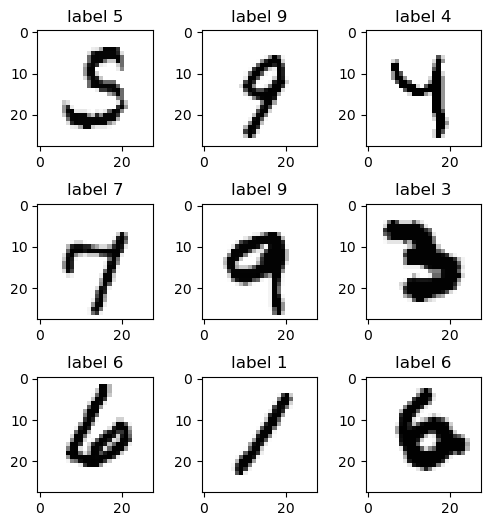

In [7]:
plt.rcParams['figure.figsize'] = (6,6)  # 그림 크기 정하기

for i in range(9): # range(9)는 0부터 8까지 정수 9개
    plt.subplot(3,3,i+1) # 3x3 subplot을 하나씩 채워나감
    num = np.random.randint(0, len(x_train))  # 훈련 세트에서 임의로 손글씨 하나를 고름
    plt.imshow(x_train[num], cmap='Greys')
    plt.title("label {}". format(y_train[num]))
    plt.subplots_adjust(hspace=.5) # 하위그림의 위아래 간격을 조정

### 출력변수 및 입력변수 변환

**출력변수 원-핫 인코딩(one-hot encoding)**

`y` 변수 레이블을 "원-핫" 인코딩해야 하는데, `keras` 내장 함수인 `np_utils.to_categorical()`을 이용하면 된다. 이 함수의 사용법은 가령 클래스가 0부터 9까지 10개의 레이블이 있을 때, 예를 들어 레이블 3의 원-핫 표현은 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]이다. 즉 인덱스 3의 값을 제외하고 모두 0을 갖는 배열이다. 

In [8]:
to_categorical(3, num_classes=10)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32)

출력변수 `y`를 모두 원-핫 인코딩하면, `y`는 원래의 1차원 배열에서 2차원 배열로 바뀌게 된다.

In [9]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_train.shape, y_test.shape

((60000, 10), (10000, 10))

**입력변수 배열 변환**

입력변수 `x`의 각 숫자 이미지는 $28\times28=784$ 픽셀에 대해 회색조 스케일 값을 지니고 있다. 이렇게 각 숫자 이미지에 대해 2차원으로 기록된 픽셀 데이터를 첫 번째 행부터 차례대로 붙여나감으로써(즉 첫 번째 행의 마지막 값 다음에 두 번째 행의 첫 번째 값이 위치하는 방식으로) 전체 28개 행을 하나의 벡터로 연결하기로 한다. 즉 2차원 픽셀 배열을 1차원 배열로 바꾸는 것이다. 

이 작업은 `numpy`의 `reshape` 함수를 사용하면 된다. 가령 `x_train` 변수에 대해서는 `np.reshape(x_train, (60000, 784))` 식으로 하면 된다. 즉 `x_train` 변수의 6만 개 관측 각각의 형태(shape)를 784개 원소를 가진 배열로 바꾸는 것이다. 

In [10]:
# resize
x_train = np.reshape(x_train, (60000, 784))
x_test = np.reshape(x_test, (10000, 784))

x_train.shape, x_test.shape

((60000, 784), (10000, 784))

`x` 변수가 어떤 형태로 바뀌었는지 훈련 세트의 첫 번째 관측을 호출해서 앞의 변환 전 결과와 비교해보자.

In [11]:
x_train[0].round(1)

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

**입력변수 척도 변환**

신경망은 입력변수의 척도(scale)에 다소 민감하다. ridge 및 lasso 정규화가 척도의 영향을 받는 것과 비슷한 맥락이다. MNIST 데이터세트에서 입력은 0에서 255 사이의 8비트 회색조 스케일 값이므로 우리는 이것을 255로 나누어 0에서 1사이의 값을 갖도록 정규화하기로 한다.

In [12]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

### 신경망 모델 설정

주어진 데이터로 신경망을 피팅하기 위해 먼저 모델 구조를 설정해야 한다. 아래 모델 설정 코딩의 전체 구조는 `modelnn`이라는 이름의 모델 객체를 생성하고, `Sequential()` 함수를 사용하여 순차적인 방식으로 레이어에 대한 세부 정보를 추가할 것임을 명령한다. 그런 다음, `modelnn` 객체에 `add()` 메소드를 통해 필요한 유형의 레이어와 정보를 추가해나가는 방식을 취한다. 

먼저 `modelnn.add(Dense(256, input_dim=784))`은 입력층에 784개 입력 유닛이 있고, 이것이 256개 유닛의 은닉층으로 전달되는 구조를 설정한 것이다. 그 다음 `modelnn.add(Activation('relu'))`은 바로 위에서 규정한 첫 번째 은닉층이 ReLU 활성화 함수를 사용한다는 것을 의미한다. 그 다음 `modelnn.add(Dropout(0.4))`은 드롭아웃 정규화(dropout regularization)를 지정한 것이다. 드롭아웃은 최적화 과정을 반복하는 동안 첫 번째 은닉층의 256개 활성화 중 임의의 40%가 0으로 설정되는 것을 의미한다.

그 다음 두 번째 은닉층도 첫 번째 은닉층과 비슷한 방식으로 설정돼있다. 즉 128개의 은닉 유닛이 있고, 이것 역시 ReLU 활성화 함수를 사용하며, 30%의 드롭아웃 정규화를 거친다. 

마지막 층은 "softmax" 활성화 함수(식 15.6)를 사용하는 출력층으로서 10개 클래스의 확률을 도출하는 부분이다. 마지막으로 `summary()`를 사용하여 모델 요약을 통해 모든 것이 올바른지 확인한다. 

In [13]:
# 2개의 은닉층을 지닌 신경망 모델 설정
modelnn = Sequential()
modelnn.add(Dense(256, input_dim=784))
modelnn.add(Activation('relu'))
modelnn.add(Dropout(0.4))
modelnn.add(Dense(128))
modelnn.add(Activation('relu'))
modelnn.add(Dropout(0.3))
modelnn.add(Dense(10))
modelnn.add(Activation('softmax'))

# modelnn.summary()

`modelnn.summary()`을 실행시키면 표가 제공되는데, 첫번째 은닉층의 유닛을 256개로 하고 두 번째 은닉층의 유닛을 128개로 할 경우 추정해야 하는 파라미터는 총 235,146개임을 확인할 수 있다. 위 결과 표에서 첫 번째 열의 항목 중 `dense`, `activation`, `dropout`에 `_1`, `_2` 등의 첨자가 표시돼있는데, 이는 별 의미가 없다. 모델을 바꾸지 않고 동일한 모델을 다시 피팅하면 첨자 숫자가 바뀌게 되는데, `Sequential()`이 호출될 때마다 첨자의 값이 커진다.

### ChatGPT Q&A

>**다음을 실행했는데 경고가 나왔다??**
>
>     modelnn = Sequential()  
>     modelnn.add(Dense(256, input_dim=784))  
>     modelnn.add(Activation('relu'))  
>     modelnn.add(Dropout(0.4))  
>     modelnn.add(Dense(128))  
>     modelnn.add(Activation('relu'))  
>     modelnn.add(Dropout(0.3))  
>     modelnn.add(Dense(10))  
>     modelnn.add(Activation('softmax'))  
>     modelnn.summary()
>
>**경고 및 오류 내용**
>
>WARNING:tensorflow:From C:\Users\pilsu\anaconda3\Lib\site-packages\keras\src\backend.py:873: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

---

>이 경고는 TensorFlow 1.x에서 사용되던 `tf.get_default_graph`가 TensorFlow 2.x에서는 더 이상 권장되지 않기 때문에 발생합니다. TensorFlow 2.x에서는 대부분의 작업을 실행하기 위해 명시적으로 그래프를 생성하고 사용할 필요가 없으며, TensorFlow가 자동으로 백그라운드에서 처리합니다. 그러나 여기서 발생하는 경고는 `keras` 패키지 내부의 코드에서 발생하는 것으로, 사용자가 직접 작성한 코드에 의한 것은 아닙니다.
>
>경고를 해결하기 위한 직접적인 방법은 사용자 코드에서 `tf.get_default_graph`를 호출하지 않는 한 존재하지 않습니다. 그러나 이 경고는 실행에는 영향을 주지 않으며, 단지 사용 중인 TensorFlow의 일부 기능이 미래에 제거될 수 있음을 알리는 것입니다. 코드가 정상적으로 실행되므로, 이 경고는 무시해도 괜찮습니다.

### 모델 실행

**컴파일링**

`keras`에서 모델을 설정한 다음에는 이를 실행시킨다. 이는 세 단계로 나뉘는데, `compile()` 메소드를 사용하여 모델을 컴파일하고, `fit()` 메소드를 사용하여 모델을 훈련하며, `evaluate()` 메소드를 사용하여 모델 성능을 평가한다.

먼저 아래의 컴파일링 부분을 보면, 피팅 알고리듬과 관련된 세부 정보를 `modelnn`에 설정한다. 우선 손실함수에 있어서는 식 15.7의 교차 엔트로피(cross-entropy) 함수를 최소화하도록 했다. 다음으로 `optimizer`에 있어서는 `keras`에 몇 가지 선택 사항이 있다. 가장 기본적인 `SGD`(확률적 경사하강법)을 비롯해 `RMSprop`(Root Mean Squared Propagation), `Adam`(Adaptive Moments) 등이 있다. 아래에서 우리는 `RMSprop`을 선택했다. 마지막으로 성과 메트릭(performance metric)은 모델의 피팅 성과를 평가하는 기준으로서 `keras`의 기본 메트릭은 손실(loss)이지만, 여기에서는 정확도(accuracy)를 추가시켰다.

In [14]:
modelnn.compile(
    loss='categorical_crossentropy',
    optimizer='RMSprop',
    metrics=['accuracy']
)

>**옵티마이저(optimizer) 부연 설명**
>
> 옵티마이저(optimizer)는 최적화 알고리듬의 작동 방식으로서 모델의 파라미터가 최적화로 진행되는(다시 말하면 손실함수를 최소화시키는 파라미터를 찾는) 방법을 결정하는 알고리듬이다. 옵티마이저는 딥러닝 모델의 정확도에 영향을 미치고 모델의 훈련 속도에도 상당한 영향을 미친다. 그런 점에서 옵티마이저는 손실함수와 함께 모든 딥러닝 모델의 중추이다. 파라미터 업데이트를 위해 데이터 전체를 기울기(gradient) 계산에 이용하는 방식인 **일괄(batch) 경사하강법**은 데이터 크기가 커짐에 따라 추정 속도가 느려지는 단점이 있다. 이 문제를 해결하기 위한 것이 앞에서 설명한 **확률적 경사하강법**(SGD)이다. SGD에서는 각 반복적 업데이트에서 전체 데이터가 아니라 일부를 무작위로 선택한다. `keras`에서는 다양한 옵티마이저를 제공하고 있는데 SGD가 가장 기본이 된다. 사실, 다른 모든 옵티마이저는 SGD의 기본 아이디어를 약간씩 발전시킨 것이라 할 수 있으며, 기본적으로는 동일한 아이디어가 사용된다. SGD 옵티마이저는 Keras에서 가장 기본이 되지만 실제로 많이 사용되지는 않는다. 이를 더욱 발전시킨 다른 옵티마이저들이 있기 때문이다. 그중 하나인 `Adagrad` 옵티마이저는 SGD에 **적응적(adaptive) 학습률**이라는 아이디어를 가미한 것이다. Adagrad는 파라미터가 업데이트되는 빈도(크기)에 따라 학습률이 달라지는 것으로, 최적화 진행 과정에서 파라미터의 업데이트가 많을수록 (이미 최적화가 많이 진행되었다고 보고) 업데이트의 크기를 줄이는 방식이다. `Adagrad`의 한 가지 단점은 학습률이 너무 작아져 최소값에 도달하기도 전에 학습률이 0에 수렴해버릴 수도 있다는 점이다. 이런 단점을 개선하기 위해 등장한 기법이 `RMSprop`, `Adam` 등이다.

**모델 피팅**

모델 실행의 두 번째 단계는 훈련 데이터를 제공하여 설정한 모델을 피팅하는 것이다. `fit()` 메소드를 통해 훈련 데이터, 그리고 두 개의 피팅 옵션인 `epochs` 및 `batch_size`를 정한다. 아래에서 `batch_size`를 128로 한다는 것은 최적화의 각 과정에서 알고리듬이 기울기 계산을 위해 128개의 훈련 관측을 무작위로 선택하는 것을 의미한다. 관측을 무작위로 선택하는 데다 드롭아웃의 임의성, 검증 세트의 임의성 등으로 인해 **실행할 때마다 피팅 결과가 약간씩 달라지는** 것을 확인할 수 있을 것이다. 

관측 전체를 처리하는 데 몇 번의 SGD 스텝이 필요한지를 생각해보자. 여기에서 우리는 검증 분할(`validation split`)로 20%를 지정했으므로 훈련 세트의 60,000개 관측 중 80%인 48,000개에 대해 훈련 작업이 수행된다. 그런데 한 번의 SGD 스텝에 128개의 훈련 관측이 사용되므로 관측 전체에 대해서는 약 48,000/128 ≈ 375번의 SGD 스텝을 거치게 된다. 즉 에포크 하나 당 375번의 SGD 스텝을 거치게 된다. 

In [15]:
results = modelnn.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=0  # 출력 억제
)

**피팅 과정 그림 그리기**

바로 앞에서 피팅 결과를 `results`라는 이름으로 지정했고, 그것을 `history` 메소드와 `plot` 함수를 사용하여 피팅 과정을 그림으로 그릴 수 있다. 아래는 앞의 그림 15.6과 유사한 그림을 생성하는 코딩이다. 

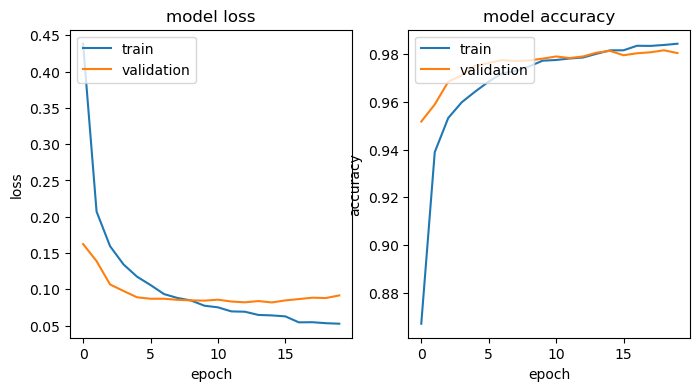

In [16]:
fig = plt.figure(figsize=(8,4))

# 손실함수(loss) 그림
plt.subplot(121)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

# 정확도(accuracy) 그림
plt.subplot(122)
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**모델 성능 평가**

`evaluate` 메소드를 이용하면, 훈련 세트에 대한 추정 결과를 바탕으로 테스트 세트에 대해 정확도를 구할 수 있다. 

In [17]:
loss, acc = modelnn.evaluate(x_test, y_test, batch_size = 128)
print("\n신경망 모델 테스트 세트 정확도: %.2f%%" % (100.0 * acc))

 1/79 [..............................] - ETA: 4s - loss: 0.0271 - accuracy: 0.9922

14/79 [====>.........................] - ETA: 0s - loss: 0.1172 - accuracy: 0.9749

27/79 [=========>....................] - ETA: 0s - loss: 0.1096 - accuracy: 0.9763

38/79 [=============>................] - ETA: 0s - loss: 0.1136 - accuracy: 0.9747

48/79 [=================>............] - ETA: 0s - loss: 0.1024 - accuracy: 0.9769

58/79 [=====================>........] - ETA: 0s - loss: 0.0928 - accuracy: 0.9793

69/79 [=========================>....] - ETA: 0s - loss: 0.0803 - accuracy: 0.9820

79/79 [==============================] - ETA: 0s - loss: 0.0806 - accuracy: 0.9823

79/79 [==============================] - 0s 5ms/step - loss: 0.0806 - accuracy: 0.9823



신경망 모델 테스트 세트 정확도: 98.23%


### 참고: 로지스틱 모델 추정 결과

동일한 MNIST 데이터세트에 대해 신경망이 아니라 **다항(multinomial) 로지스틱 회귀** 모델로 손글씨 인식 문제를 처리해보자. 파이썬에 이를 위한 모듈이 따로 있지만, 우리가 위에서 사용한 `keras`를 사용하여 로지스틱 모델을 피팅하는 것도 가능하다. 즉 앞의 신경망 모델에서 (2개의) 은닉층만 빼고, 입력층과 출력층은 그대로 놔두면 된다. 이렇게 하면 추정해야 하는 가중치는 7,850개로 줄어든다. 아래 결과를 보면 테스트 세트에 대한 정확도가 93% 수준으로서 앞의 신경망 모델 정확도(98% 수준)보다 훨씬 낮은 것을 알 수 있다.

In [18]:
# 입력층과 출력층만을 지닌 모델 설정
modellr = Sequential()
modellr.add(Dense(10, input_dim=784))
modellr.add(Activation('softmax'))

# modellr.summary()

In [19]:
modellr.compile(
    loss='categorical_crossentropy',
    optimizer='RMSprop',
    metrics=['accuracy']
)

In [20]:
modellr.fit(
    x_train, y_train,
    epochs=20, 
    batch_size=128, 
    validation_split=0.2,
    verbose=0  # 출력 억제
)

In [21]:
loss, acc = modellr.evaluate(x_test, y_test, batch_size = 128)
print("\n로지스틱 회귀 모델 테스트 세트 정확도: %.2f%%" % (100.0 * acc))

 1/79 [..............................] - ETA: 5s - loss: 0.1741 - accuracy: 0.9609

17/79 [=====>........................] - ETA: 0s - loss: 0.3384 - accuracy: 0.9021

33/79 [===========>..................] - ETA: 0s - loss: 0.3384 - accuracy: 0.9067

47/79 [================>.............] - ETA: 0s - loss: 0.3127 - accuracy: 0.9142

59/79 [=====================>........] - ETA: 0s - loss: 0.2894 - accuracy: 0.9208

73/79 [==========================>...] - ETA: 0s - loss: 0.2651 - accuracy: 0.9281

79/79 [==============================] - 0s 4ms/step - loss: 0.2669 - accuracy: 0.9268



로지스틱 회귀 모델 테스트 세트 정확도: 92.68%
